In [1]:
import os
import json

# ── Monter Google Drive ─────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = '/content/drive/MyDrive/FinalAutoEncoder'
DATASET_DIR = f'{PROJECT_DIR}/datasets'
MODEL_DIR   = f'{PROJECT_DIR}/models'
RESULTS_DIR = f'{PROJECT_DIR}/results'

for d in [PROJECT_DIR, DATASET_DIR, MODEL_DIR, RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)

print("Drive est bien monté")
print(f"   Projet : {PROJECT_DIR}")

# ── Configurer Kaggle ───────────────────────────────────────────
KAGGLE_USERNAME = "r1ppxrr"
KAGGLE_KEY      = "c9bae231d5eeaf2371400614d7b95196"

os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
with open(os.path.expanduser('~/.kaggle/kaggle.json'), 'w') as f:
    json.dump({"username": KAGGLE_USERNAME, "key": KAGGLE_KEY}, f)

!chmod 600 ~/.kaggle/kaggle.json
!pip install kaggle -q

print("\n Kaggle est bien configuré")

Mounted at /content/drive
Drive est bien monté
   Projet : /content/drive/MyDrive/FinalAutoEncoder

 Kaggle est bien configuré


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import gc
import psutil
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection    import train_test_split
from sklearn.preprocessing      import LabelEncoder, MinMaxScaler
from sklearn.metrics            import (classification_report,
                                        confusion_matrix,
                                        accuracy_score,
                                        f1_score,
                                        roc_auc_score,
                                        roc_curve)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow                 import keras
from tensorflow.keras           import layers, regularizers, callbacks
from tensorflow.keras.utils     import to_categorical

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

def check_ram():
    ram  = psutil.virtual_memory()
    free = ram.available / 1e9
    used = ram.used / 1e9
    tot  = ram.total / 1e9
    print(f"RAM : {used:.1f}GB utilisés | {free:.1f}GB libres | {tot:.1f}GB total")
    if free < 1.5:
        gc.collect()
check_ram()

RAM : 1.4GB utilisés | 11.9GB libres | 13.6GB total


In [3]:
import glob

csv_in_drive = glob.glob(f'{DATASET_DIR}/*.csv')

if csv_in_drive:
    print(f"Dataset déjà dans Drive ({len(csv_in_drive)} fichiers)")
    for f in csv_in_drive:
        size = os.path.getsize(f) / 1e6
        print(f"{os.path.basename(f)} → {size:.1f} MB")
else:
    os.makedirs('/content/cicids_raw', exist_ok=True)

    !kaggle datasets download -d chethuhn/network-intrusion-dataset -p /content/cicids_raw -q

    print("Téléchargement du DATASET est terminé")
    print("Décompression")

    import zipfile
    zip_path = '/content/cicids_raw/network-intrusion-dataset.zip'

    with zipfile.ZipFile(zip_path, 'r') as z:
        all_csv = [f for f in z.namelist() if f.endswith('.csv')]
        print(f"\n Fichiers disponibles ({len(all_csv)}) :")
        for f in all_csv:
            size = z.getinfo(f).file_size / 1e6
            print(f"{f} → {size:.1f} MB")

        target = next(
            (f for f in all_csv if 'Wednesday' in f or 'wednesday' in f),
            all_csv[0]
        )
        print(f"\n Extraction : {target}")
        z.extract(target, '/content/cicids_raw/')

    extracted = glob.glob('/content/cicids_raw/*.csv')
    for f in extracted:
        dest = f'{DATASET_DIR}/{os.path.basename(f)}'
        !cp "{f}" "{dest}"
        print(f"Sauvegardé : {os.path.basename(f)}")

    !rm -rf /content/cicids_raw
    gc.collect()
    print("Dataset prêt dans Drive")

Dataset URL: https://www.kaggle.com/datasets/chethuhn/network-intrusion-dataset
License(s): CC0-1.0
Téléchargement du DATASET est terminé
Décompression

 Fichiers disponibles (8) :
Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv → 77.1 MB
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv → 76.9 MB
Friday-WorkingHours-Morning.pcap_ISCX.csv → 58.3 MB
Monday-WorkingHours.pcap_ISCX.csv → 176.9 MB
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv → 83.1 MB
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv → 52.0 MB
Tuesday-WorkingHours.pcap_ISCX.csv → 135.1 MB
Wednesday-workingHours.pcap_ISCX.csv → 225.2 MB

 Extraction : Wednesday-workingHours.pcap_ISCX.csv
Sauvegardé : Wednesday-workingHours.pcap_ISCX.csv
Dataset prêt dans Drive


In [4]:
def map_label(lbl):
    lbl = str(lbl).upper().strip()
    if 'BENIGN'  in lbl:                   return 'BENIGN'
    if 'DOS'     in lbl or 'DDOS' in lbl:  return 'DoS'
    if 'PORTSCAN' in lbl or 'SCAN' in lbl: return 'Probe'
    if 'BRUTE'   in lbl or 'FTP'  in lbl \
       or 'SSH'  in lbl:                   return 'R2L'
    if 'BOT'     in lbl:                   return 'Bot'
    if 'WEB'     in lbl or 'SQL'  in lbl \
       or 'XSS'  in lbl:                   return 'WebAttack'
    if 'INFILTR' in lbl:                   return 'U2R'
    if 'HEART'   in lbl:                   return 'DoS'
    return 'Other'

csv_files  = glob.glob(f'{DATASET_DIR}/*.csv')
CHUNK_SIZE = 50000
MAX_LIGNES = 180000

print(f"Fichier : {os.path.basename(csv_files[0])}")
print(f"Lecture par chunks ({CHUNK_SIZE:,} lignes) — Max : {MAX_LIGNES:,}")

frames = []
total  = 0

for i, chunk in enumerate(pd.read_csv(
        csv_files[0],
        chunksize=CHUNK_SIZE,
        low_memory=False)):

    chunk.columns = chunk.columns.str.strip()
    chunk.replace([np.inf, -np.inf], np.nan, inplace=True)

    lbl_col = next(
        (c for c in chunk.columns if 'label' in c.lower()), None)
    if lbl_col is None:
        continue

    chunk[lbl_col] = chunk[lbl_col].apply(map_label)
    chunk.rename(columns={lbl_col: 'label'}, inplace=True)

    frames.append(chunk)
    total += len(chunk)
    print(f"   Chunk {i+1} : {total:,} lignes")

    if total >= MAX_LIGNES:
        print(f"Limite atteinte → arrêt")
        break

df = pd.concat(frames, ignore_index=True)
del frames
gc.collect()

print(f"\n Dataset : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"\n Distribution :")
print(df['label'].value_counts())

check_ram()

Fichier : Wednesday-workingHours.pcap_ISCX.csv
Lecture par chunks (50,000 lignes) — Max : 180,000
   Chunk 1 : 50,000 lignes
   Chunk 2 : 100,000 lignes
   Chunk 3 : 150,000 lignes
   Chunk 4 : 200,000 lignes
Limite atteinte → arrêt

 Dataset : 200,000 lignes × 79 colonnes

 Distribution :
label
DoS       129971
BENIGN     70029
Name: count, dtype: int64
RAM : 1.7GB utilisés | 11.6GB libres | 13.6GB total


In [5]:
gc.collect()
tf.keras.backend.clear_session()

print("PRÉTRAITEMENT")
check_ram()

# ── A. Séparation features/labels ─────────────────────────────────
print("\n[A] Séparation features / labels")

drop_cols = ['label']
feat_cols = [
    c for c in df.columns
    if c not in drop_cols
    and df[c].dtype in [np.float64, np.float32, np.int64, np.int32]
]

X_raw = df[feat_cols].values.astype(np.float32)
y_raw = df['label'].values.copy()

del df
gc.collect()

print(f"Features : {X_raw.shape[1]}")
print(f"Lignes   : {X_raw.shape[0]:,}")
check_ram()

# ── B. Nettoyage ───────────────────────────────────────────────────
print("\n[B] Nettoyage")

X_raw = np.where(np.isinf(X_raw), np.nan, X_raw)
X_raw = X_raw.astype(np.float32)

col_medians = np.nanmedian(X_raw, axis=0)
nan_mask    = np.isnan(X_raw)
for j in range(X_raw.shape[1]):
    X_raw[nan_mask[:, j], j] = col_medians[j]

std_vals  = np.std(X_raw, axis=0)
good_cols = std_vals > 0
X_raw     = X_raw[:, good_cols]
feat_cols = [feat_cols[i] for i in range(len(feat_cols)) if good_cols[i]]

gc.collect()
print(f"Features après nettoyage : {X_raw.shape[1]}")

# ── C. Encodage des labels ─────────────────────────────────────────
print("\n[C] Encodage des labels")

le          = LabelEncoder()
y_enc       = le.fit_transform(y_raw)
N_CLASSES   = len(le.classes_)
CLASS_NAMES = list(le.classes_)

del y_raw
gc.collect()

print(f"Classes : {N_CLASSES} → {CLASS_NAMES}")

# ── D. Sélection Top 40 features par variance ─────────────────────
print("\n[D] Sélection Top 40 features...")

N_TOP       = 40
variances   = np.var(X_raw, axis=0)
top_indices = np.argsort(variances)[::-1][:N_TOP]
X_selected  = X_raw[:, top_indices].astype(np.float32)
K           = X_selected.shape[1]

del X_raw
gc.collect()

print(f"Features sélectionnées : {K}")
check_ram()

# ── E. Split train / val / test ────────────────────────────────────
print("\n[E] Split des données")

X_tr, X_te, y_tr, y_te = train_test_split(
    X_selected, y_enc,
    test_size=0.15,
    random_state=SEED,
    stratify=y_enc
)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_tr, y_tr,
    test_size=0.12,
    random_state=SEED,
    stratify=y_tr
)

del X_selected
gc.collect()

print(f"Train      : {X_tr.shape[0]:,}")
print(f"Validation : {X_val.shape[0]:,}")
print(f"Test       : {X_te.shape[0]:,}")

# ── F. Normalisation MinMaxScaler ──────────────────────────────────
print("\n[F] Normalisation")

scaler = MinMaxScaler()
X_tr   = scaler.fit_transform(X_tr).astype(np.float32)
X_val  = scaler.transform(X_val).astype(np.float32)
X_te   = scaler.transform(X_te).astype(np.float32)

print("Normalisation est bien terminée")

# ── G. One-Hot Encoding ────────────────────────────────────────────
print("\n[G] One-Hot Encoding...")

y_tr_cat  = to_categorical(y_tr,  N_CLASSES)
y_val_cat = to_categorical(y_val, N_CLASSES)
y_te_cat  = to_categorical(y_te,  N_CLASSES)

print(f"X_train : {X_tr.shape}")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {X_te.shape}")

check_ram()

PRÉTRAITEMENT
RAM : 1.7GB utilisés | 11.6GB libres | 13.6GB total

[A] Séparation features / labels
Features : 78
Lignes   : 200,000
RAM : 1.8GB utilisés | 11.5GB libres | 13.6GB total

[B] Nettoyage
Features après nettoyage : 68

[C] Encodage des labels
Classes : 2 → ['BENIGN', 'DoS']

[D] Sélection Top 40 features...
Features sélectionnées : 40
RAM : 1.7GB utilisés | 11.6GB libres | 13.6GB total

[E] Split des données
Train      : 149,600
Validation : 20,400
Test       : 30,000

[F] Normalisation
Normalisation est bien terminée

[G] One-Hot Encoding...
X_train : (149600, 40)
X_val   : (20400, 40)
X_test  : (30000, 40)
RAM : 1.7GB utilisés | 11.6GB libres | 13.6GB total


In [6]:
gc.collect()
tf.keras.backend.clear_session()

# ── Bloc Transformer ───────────────────────────────────────────────
def transformer_block(x, num_heads, ff_dim, dropout_rate=0.1):
    """
    Un bloc Transformer complet :
    1. Multi-Head Self-Attention
    2. Add & LayerNorm
    3. Feed-Forward Network
    4. Add & LayerNorm
    """
    embed_dim = x.shape[-1]

    # Multi-Head Self-Attention
    attn_output = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=embed_dim // num_heads,
        dropout=dropout_rate
    )(x, x)
    attn_output = layers.Dropout(dropout_rate)(attn_output)
    # Add & Norm (connexion résiduelle)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)

    # Feed-Forward Network
    ffn = layers.Dense(ff_dim, activation='relu')(out1)
    ffn = layers.Dropout(dropout_rate)(ffn)
    ffn = layers.Dense(embed_dim)(ffn)
    ffn = layers.Dropout(dropout_rate)(ffn)
    # Add & Norm (connexion résiduelle)
    out2 = layers.LayerNormalization(epsilon=1e-6)(out1 + ffn)

    return out2


def build_model(input_dim, n_classes):
    """
    Construit le modèle Autoencoder + Transformer.
    input_dim : nombre de features (K=40)
    n_classes : nombre de classes (7)
    """

    inputs = keras.Input(shape=(input_dim,), name='input')

    # ══ PARTIE 1 : AUTOENCODER (Encodeur) ═══════════════════════
    # Compresse 40 features → 64 → 32 (représentation latente)
    enc = layers.Dense(
        64,
        activation='relu',
        kernel_initializer='he_normal',
        kernel_regularizer=regularizers.l2(1e-4),
        name='enc_1'
    )(inputs)
    enc = layers.BatchNormalization(name='enc_bn1')(enc)
    enc = layers.Dropout(0.2, name='enc_drop1')(enc)

    enc = layers.Dense(
        32,
        activation='relu',
        kernel_initializer='he_normal',
        kernel_regularizer=regularizers.l2(1e-4),
        name='enc_2'
    )(enc)
    enc = layers.BatchNormalization(name='enc_bn2')(enc)
    enc = layers.Dropout(0.2, name='enc_drop2')(enc)
    # enc a maintenant shape (None, 32)

    # ══ PARTIE 2 : TRANSFORMER ════════════════════════════════════
    # Le Transformer attend des séquences 3D : (batch, seq_len, embed_dim)
    # On transforme (None, 32) → (None, 4, 8) : 4 patches de 8 dims
    # num_patches=4, patch_dim=8 → 4×8 = 32
    num_patches = 4
    patch_dim   = 32 // num_patches   # = 8

    # Reshape : (None, 32) → (None, 4, 8)
    x = layers.Reshape(
        (num_patches, patch_dim),
        name='reshape_for_transformer'
    )(enc)

    # Projection vers embed_dim=32 pour l'attention
    embed_dim = 32
    x = layers.Dense(embed_dim, name='patch_embed')(x)

    # Bloc Transformer 1
    x = transformer_block(x, num_heads=4, ff_dim=64, dropout_rate=0.1)
    # Bloc Transformer 2
    x = transformer_block(x, num_heads=4, ff_dim=64, dropout_rate=0.1)

    # ══ PARTIE 3 : CLASSIFIEUR ════════════════════════════════════
    # GlobalAveragePooling : (None, 4, 32) → (None, 32)
    x = layers.GlobalAveragePooling1D(name='global_avg')(x)
    x = layers.Dropout(0.3, name='drop_cls1')(x)

    x = layers.Dense(
        64,
        activation='relu',
        kernel_initializer='he_normal',
        name='cls_dense'
    )(x)
    x = layers.BatchNormalization(name='cls_bn')(x)
    x = layers.Dropout(0.25, name='drop_cls2')(x)

    # Sortie Softmax
    outputs = layers.Dense(
        n_classes,
        activation='softmax',
        name='output'
    )(x)

    model = keras.Model(inputs, outputs, name='IDS_Transformer_AE')
    return model


model = build_model(K, N_CLASSES)
model.summary()

print(f"\n Modèle Transformer+AE construit")
print(f"   Paramètres  : {model.count_params():,}")
print(f"   Input shape : ({K},)")
print(f"   Output      : ({N_CLASSES},) → {CLASS_NAMES}")

Model: "IDS_Transformer_AE"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 40)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_1 (Dense)       │ (None, 64)        │      2,624 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_bn1             │ (None, 64)        │        256 │ enc_1[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_drop1 (Dropout) │ (None, 64)        │          0 │ enc_bn1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_2 (Dense)       │ (None, 32)        │      2,080 │ enc_drop1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_bn2             │ (None, 32)        │        128 │ enc_2[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_drop2 (Dropout) │ (None, 32)        │          0 │ enc_bn2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_for_transf… │ (None, 4, 8)      │          0 │ enc_drop2[0][0]   │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_embed (Dense) │ (None, 4, 32)     │        288 │ reshape_for_tran… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 4, 32)     │      4,224 │ patch_embed[0][0… │
│ (MultiHeadAttentio… │                   │            │ patch_embed[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 4, 32)     │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 4, 32)     │          0 │ patch_embed[0][0… │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 4, 32)     │         64 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 4, 64)     │      2,112 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 4, 64)     │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 4, 32)     │      2,080 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 4, 32)     │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 4, 32)     │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 4, 32)     │         64 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 4, 32)     │      4,224 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 24,962 (97.51 KB)

 Trainable params: 24,642 (96.26 KB)

 Non-trainable params: 320 (1.25 KB)


 Modèle Transformer+AE construit
   Paramètres  : 24,962
   Input shape : (40,)
   Output      : (2,) → ['BENIGN', 'DoS']


In [7]:
gc.collect()
tf.keras.backend.clear_session()

# Reconstruire après clear_session
def build_model(input_dim, n_classes):
    inputs = keras.Input(shape=(input_dim,), name='input')

    enc = layers.Dense(64, activation='relu',
        kernel_initializer='he_normal',
        kernel_regularizer=regularizers.l2(1e-4),
        name='enc_1')(inputs)
    enc = layers.BatchNormalization(name='enc_bn1')(enc)
    enc = layers.Dropout(0.2, name='enc_drop1')(enc)

    enc = layers.Dense(32, activation='relu',
        kernel_initializer='he_normal',
        kernel_regularizer=regularizers.l2(1e-4),
        name='enc_2')(enc)
    enc = layers.BatchNormalization(name='enc_bn2')(enc)
    enc = layers.Dropout(0.2, name='enc_drop2')(enc)

    num_patches = 4
    patch_dim   = 8
    embed_dim   = 32

    x = layers.Reshape((num_patches, patch_dim),
        name='reshape_for_transformer')(enc)
    x = layers.Dense(embed_dim, name='patch_embed')(x)

    def transformer_block_inner(x, num_heads, ff_dim, rate=0.1):
        edim = x.shape[-1]
        attn = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=edim // num_heads,
            dropout=rate)(x, x)
        attn = layers.Dropout(rate)(attn)
        out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn)
        ffn  = layers.Dense(ff_dim, activation='relu')(out1)
        ffn  = layers.Dropout(rate)(ffn)
        ffn  = layers.Dense(edim)(ffn)
        ffn  = layers.Dropout(rate)(ffn)
        out2 = layers.LayerNormalization(epsilon=1e-6)(out1 + ffn)
        return out2

    x = transformer_block_inner(x, num_heads=4, ff_dim=64)
    x = transformer_block_inner(x, num_heads=4, ff_dim=64)

    x = layers.GlobalAveragePooling1D(name='global_avg')(x)
    x = layers.Dropout(0.3, name='drop_cls1')(x)
    x = layers.Dense(64, activation='relu',
        kernel_initializer='he_normal', name='cls_dense')(x)
    x = layers.BatchNormalization(name='cls_bn')(x)
    x = layers.Dropout(0.25, name='drop_cls2')(x)

    outputs = layers.Dense(n_classes, activation='softmax',
        name='output')(x)

    return keras.Model(inputs, outputs, name='IDS_Transformer_AE')


model = build_model(K, N_CLASSES)
print("Modèle reconstruit")

# ── Class weights ──────────────────────────────────────────────────
cw = compute_class_weight(
    'balanced',
    classes=np.unique(y_tr),
    y=y_tr
)
class_weight_dict = dict(enumerate(cw))
print("\n Class weights :")
for i, (cls, w) in enumerate(zip(CLASS_NAMES, cw)):
    print(f"   {cls:<12} : {w:.3f}")

# ── Paramètres ─────────────────────────────────────────────────────
EPOCHS     = 50
BATCH_SIZE = 256
LR         = 1e-3

print(f"\n  Époques    : {EPOCHS}")
print(f"   Batch size : {BATCH_SIZE}")
print(f"   LR         : {LR}")

# ── Compilation ────────────────────────────────────────────────────
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)
print("\n Modèle compilé")

# ── Callbacks ──────────────────────────────────────────────────────
BEST_MODEL = f'{MODEL_DIR}/best_transformer.keras'

cb_list = [
    callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=10,
        restore_best_weights=True,
        mode='max',
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=5,
        min_lr=1e-8,
        verbose=1
    ),
    callbacks.ModelCheckpoint(
        filepath=BEST_MODEL,
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=0
    ),
    callbacks.LambdaCallback(
        on_epoch_end=lambda epoch, logs: gc.collect()
    )
]

# ── tf.data.Dataset ────────────────────────────────────────────────
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.data.Dataset.from_tensor_slices(
    (X_tr, y_tr_cat)
).shuffle(
    buffer_size=5000,
    seed=SEED
).batch(BATCH_SIZE).prefetch(AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices(
    (X_val, y_val_cat)
).batch(BATCH_SIZE).prefetch(AUTOTUNE)

print("Dataset prêt")
check_ram()

# ── Entraînement ───────────────────────────────────────────────────

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weight_dict,
    callbacks=cb_list,
    verbose=1
)

del train_ds, val_ds
gc.collect()

print(f"\n Entraînement du model est bien terminé ")
print(f"Modèle : {BEST_MODEL}")
check_ram()

Modèle reconstruit

 Class weights :
   BENIGN       : 1.428
   DoS          : 0.769

  Époques    : 50
   Batch size : 256
   LR         : 0.001

 Modèle compilé
Dataset prêt
RAM : 1.9GB utilisés | 11.3GB libres | 13.6GB total
Epoch 1/50
585/585 ━━━━━━━━━━━━━━━━━━━━ 39s 33ms/step - accuracy: 0.8848 - auc: 0.9440 - loss: 0.4009 - precision: 0.8848 - recall: 0.8848 - val_accuracy: 0.9243 - val_auc: 0.9848 - val_loss: 0.3377 - val_precision: 0.9243 - val_recall: 0.9243 - learning_rate: 0.0010
Epoch 2/50
585/585 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9330 - auc: 0.9793 - loss: 0.3221 - precision: 0.9330 - recall: 0.9330 - val_accuracy: 0.9317 - val_auc: 0.9899 - val_loss: 0.2878 - val_precision: 0.9317 - val_recall: 0.9317 - learning_rate: 0.0010
Epoch 3/50
585/585 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9613 - auc: 0.9898 - loss: 0.2820 - precision: 0.9613 - recall: 0.9613 - val_accuracy: 0.9799 - val_auc: 0.9957 - val_loss: 0.2551 - val_precision: 0.9799 - val_recall: 0.

In [8]:
import gc
import numpy as np
from sklearn.metrics import (accuracy_score, f1_score,
                              roc_auc_score, classification_report,
                              confusion_matrix)
from tensorflow.keras.utils import to_categorical

gc.collect()
print("  Évalutaion sur le jeu de test")

# Prédictions
y_pred_proba = model.predict(X_te, batch_size=256, verbose=0)
y_pred       = np.argmax(y_pred_proba, axis=1)

# Métriques
acc  = accuracy_score(y_te, y_pred)
f1_w = f1_score(y_te, y_pred, average='weighted', zero_division=0)
f1_m = f1_score(y_te, y_pred, average='macro',    zero_division=0)

# AUC-ROC
try:
    y_te_bin = to_categorical(y_te, N_CLASSES)
    auc_list = []
    for i in range(N_CLASSES):
        if len(np.unique(y_te_bin[:, i])) > 1:
            auc_list.append(
                roc_auc_score(y_te_bin[:, i], y_pred_proba[:, i])
            )
    auc_mean = float(np.mean(auc_list))
except Exception:
    auc_mean = 0.0

print(f"\n MÉTRIQUES GLOBALES :")
print(f"  {'─'*40}")
print(f"  Accuracy          : {acc*100:.2f} %")
print(f"  F1-Score Weighted : {f1_w*100:.2f} %")
print(f"  F1-Score Macro    : {f1_m*100:.2f} %")
print(f"  AUC-ROC moyen     : {auc_mean:.4f}")
print(f"  {'─'*40}")

print(f"\n RAPPORT PAR CLASSE :")
print(classification_report(
    y_te, y_pred,
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0
))

CM = confusion_matrix(y_te, y_pred)

  Évalutaion sur le jeu de test

 MÉTRIQUES GLOBALES :
  ────────────────────────────────────────
  Accuracy          : 99.50 %
  F1-Score Weighted : 99.50 %
  F1-Score Macro    : 99.45 %
  AUC-ROC moyen     : 0.9994
  ────────────────────────────────────────

 RAPPORT PAR CLASSE :
              precision    recall  f1-score   support

      BENIGN     0.9983    0.9873    0.9928     10504
         DoS     0.9932    0.9991    0.9961     19496

    accuracy                         0.9950     30000
   macro avg     0.9957    0.9932    0.9945     30000
weighted avg     0.9950    0.9950    0.9950     30000



╔══════════════════════════════════════════════════╗
║  Entre les résultats DNN, CNN et LSTM           ║
║  Trouve les valeurs dans les fichiers summary   ║
╚══════════════════════════════════════════════════╝

── Résultats DNN ──────────────────────────────────
  DNN — Accuracy en %        : 77.46
  DNN — F1 Weighted en %     : 75.07
  DNN — F1 Macro en %        : 70.95
  DNN — AUC-ROC              : 0.8938

── Résultats CNN ──────────────────────────────────
  CNN — Accuracy en %        : 98.42 
  CNN — F1 Weighted en %     : 98.42
  CNN — F1 Macro en %        : 98.25
  CNN — AUC-ROC              : 0.9985

── Résultats LSTM ─────────────────────────────────
  LSTM — Accuracy en %       : 95.64
  LSTM — F1 Weighted en %    : 95.64
  LSTM — F1 Macro en %       : 95.58 
  LSTM — AUC-ROC             : 0.9773

 Toutes les valeurs sont enregistrées :
   DNN         → Acc:77.46%  F1W:75.07%  AUC:0.8938
   CNN         → Acc:98.42%  F1W:98.42%  AUC:0.9985
   LSTM        → Acc:95.64%  F1W:95.6

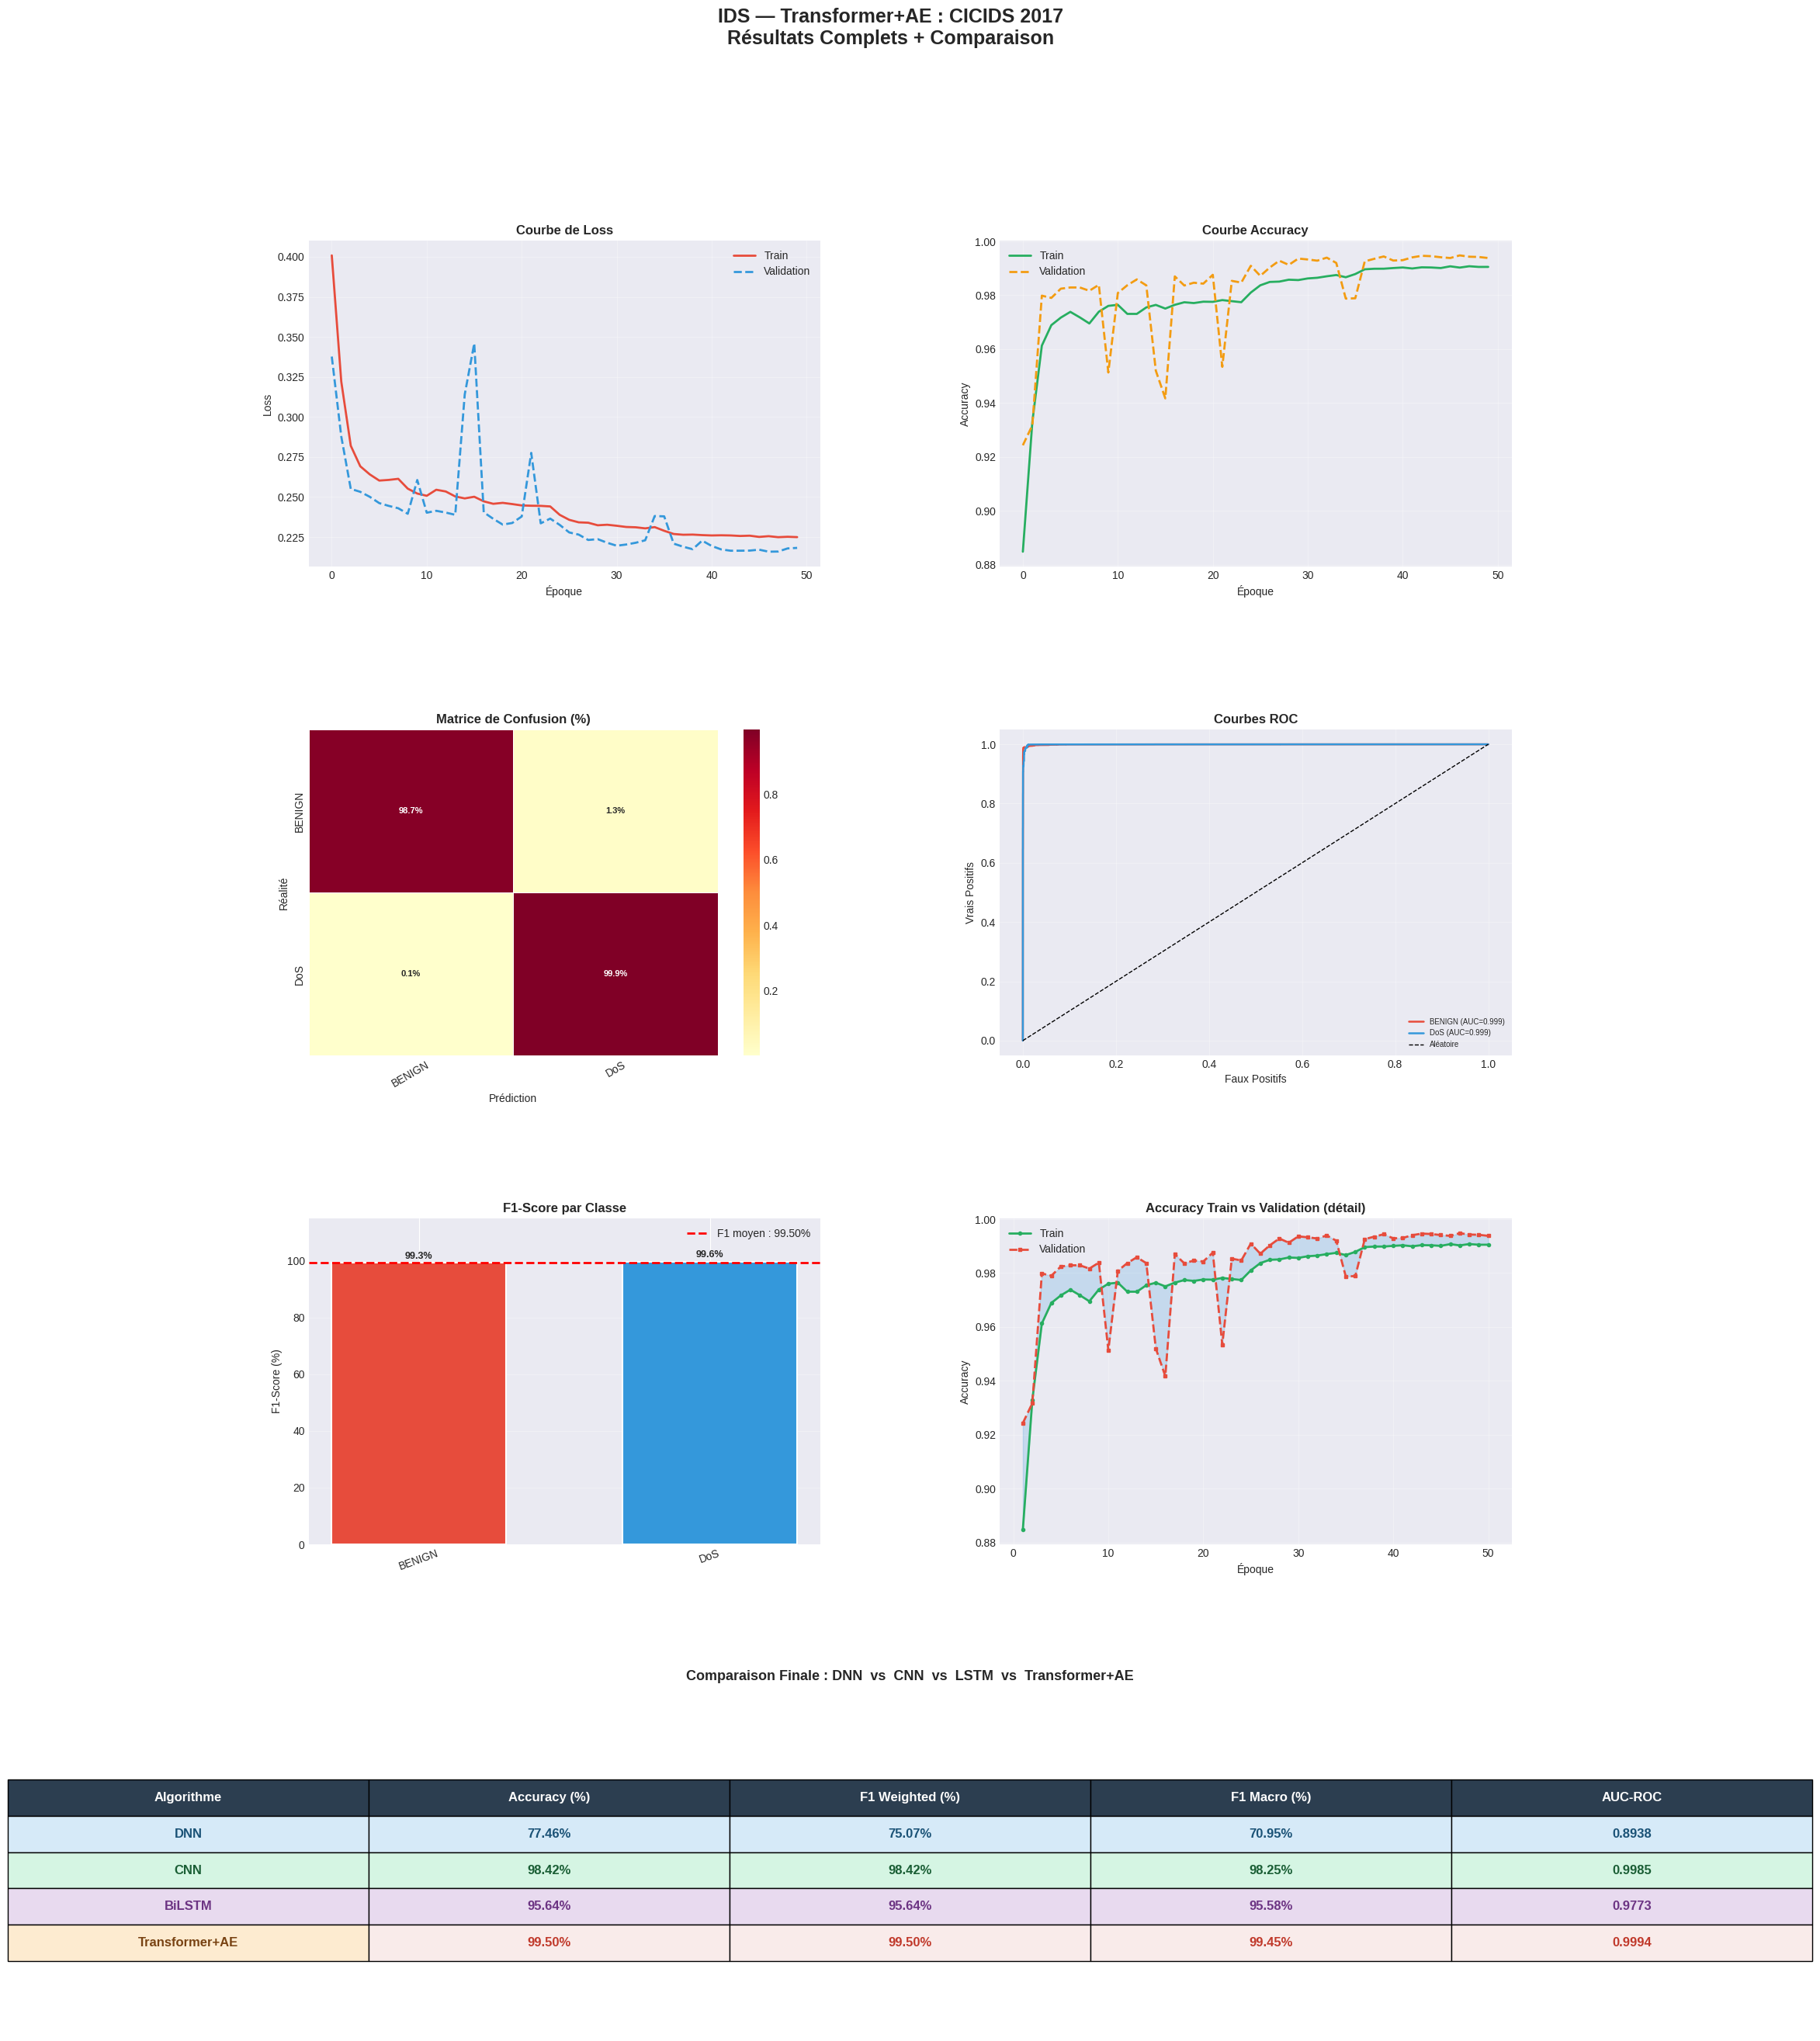

Graphe est sauvegardé : /content/drive/MyDrive/FinalAutoEncoder/results/Transformer_results.png

╔══════════════════════════════════════════════════════════════╗
║              TABLEAU COMPARATIF FINAL                      ║
╠══════════════════════════════════════════════════════════════╣
║  DNN           → Acc: 77.46%  F1W: 75.07%  AUC:0.8938  ║
║  CNN           → Acc: 98.42%  F1W: 98.42%  AUC:0.9985  ║
║  LSTM          → Acc: 95.64%  F1W: 95.64%  AUC:0.9773  ║
║  Transformer   → Acc: 99.50%  F1W: 99.50%  AUC:0.9994  ║
╚══════════════════════════════════════════════════════════════╝


In [9]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
import gc
from sklearn.metrics import roc_curve, roc_auc_score, f1_score
from tensorflow.keras.utils import to_categorical

gc.collect()

# ══════════════════════════════════════════════════════════════════
# ENTRER LES RÉSULTATS DNN, CNN ET LSTM
# Trouve ces valeurs dans les fichiers summary.txt dans Drive :
#   Drive → PFE_IDS_DNN  → results → DNN_summary.txt
#   Drive → PFE_IDS_CNN  → results → CNN_summary.txt
#   Drive → PFE_IDS_LSTM → results → LSTM_summary.txt
# ══════════════════════════════════════════════════════════════════
print("╔══════════════════════════════════════════════════╗")
print("║  Entre les résultats DNN, CNN et LSTM           ║")
print("║  Trouve les valeurs dans les fichiers summary   ║")
print("╚══════════════════════════════════════════════════╝")
print()

def demander(message):
    while True:
        try:
            return float(input(f"  {message} : "))
        except ValueError:
            print("Tape un nombre valide")

print("── Résultats DNN ──────────────────────────────────")
ACC_DNN = demander("DNN — Accuracy en %       ")
F1W_DNN = demander("DNN — F1 Weighted en %    ")
F1M_DNN = demander("DNN — F1 Macro en %       ")
AUC_DNN = demander("DNN — AUC-ROC             ")

print()
print("── Résultats CNN ──────────────────────────────────")
ACC_CNN = demander("CNN — Accuracy en %       ")
F1W_CNN = demander("CNN — F1 Weighted en %    ")
F1M_CNN = demander("CNN — F1 Macro en %       ")
AUC_CNN = demander("CNN — AUC-ROC             ")

print()
print("── Résultats LSTM ─────────────────────────────────")
ACC_LSTM = demander("LSTM — Accuracy en %      ")
F1W_LSTM = demander("LSTM — F1 Weighted en %   ")
F1M_LSTM = demander("LSTM — F1 Macro en %      ")
AUC_LSTM = demander("LSTM — AUC-ROC            ")

# Valeurs Transformer automatiques depuis Cellule 8
ACC_TR = acc * 100
F1W_TR = f1_w * 100
F1M_TR = f1_m * 100
AUC_TR = auc_mean

print()
print(" Toutes les valeurs sont enregistrées :")
print(f"   DNN         → Acc:{ACC_DNN:.2f}%  F1W:{F1W_DNN:.2f}%  AUC:{AUC_DNN:.4f}")
print(f"   CNN         → Acc:{ACC_CNN:.2f}%  F1W:{F1W_CNN:.2f}%  AUC:{AUC_CNN:.4f}")
print(f"   LSTM        → Acc:{ACC_LSTM:.2f}%  F1W:{F1W_LSTM:.2f}%  AUC:{AUC_LSTM:.4f}")
print(f"   Transformer → Acc:{ACC_TR:.2f}%  F1W:{F1W_TR:.2f}%  AUC:{AUC_TR:.4f}")
print()
print("  Génération des graphiques...")

# ══════════════════════════════════════════════════════════════════
# GRAPHIQUES
# ══════════════════════════════════════════════════════════════════
plt.style.use('seaborn-v0_8-darkgrid')

PALETTE = ['#e74c3c','#3498db','#27ae60','#f39c12',
           '#8e44ad','#1abc9c','#e67e22']

fig = plt.figure(figsize=(20, 30))
fig.suptitle(
    'IDS — Transformer+AE : CICIDS 2017\nRésultats Complets + Comparaison',
    fontsize=18, fontweight='bold', y=0.98
)
gs = gridspec.GridSpec(4, 2, figure=fig, hspace=0.50, wspace=0.35)

# ── Graphique 1 : Loss ────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(history.history['loss'],
         color='#e74c3c', lw=2, label='Train')
ax1.plot(history.history['val_loss'],
         color='#3498db', lw=2, ls='--', label='Validation')
ax1.set_title('Courbe de Loss', fontweight='bold', fontsize=12)
ax1.set_xlabel('Époque'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(True, alpha=0.3)

# ── Graphique 2 : Accuracy ────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(history.history['accuracy'],
         color='#27ae60', lw=2, label='Train')
ax2.plot(history.history['val_accuracy'],
         color='#f39c12', lw=2, ls='--', label='Validation')
ax2.set_title('Courbe Accuracy', fontweight='bold', fontsize=12)
ax2.set_xlabel('Époque'); ax2.set_ylabel('Accuracy')
ax2.legend(); ax2.grid(True, alpha=0.3)

# ── Graphique 3 : Matrice de Confusion ───────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
cm_norm = CM.astype(float) / CM.sum(axis=1, keepdims=True)
sns.heatmap(
    cm_norm, annot=True, fmt='.1%',
    cmap='YlOrRd', ax=ax3,
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    linewidths=0.5,
    annot_kws={"size": 8, "weight": "bold"}
)
ax3.set_title('Matrice de Confusion (%)', fontweight='bold', fontsize=12)
ax3.set_xlabel('Prédiction'); ax3.set_ylabel('Réalité')
ax3.tick_params(axis='x', rotation=30)

# ── Graphique 4 : Courbes ROC ─────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
y_te_bin = to_categorical(y_te, N_CLASSES)
for i, (cls_name, color) in enumerate(zip(CLASS_NAMES, PALETTE)):
    if len(np.unique(y_te_bin[:, i])) < 2:
        continue
    fpr, tpr, _ = roc_curve(y_te_bin[:, i], y_pred_proba[:, i])
    auc_i = roc_auc_score(y_te_bin[:, i], y_pred_proba[:, i])
    ax4.plot(fpr, tpr, color=color, lw=1.8,
             label=f'{cls_name} (AUC={auc_i:.3f})')
ax4.plot([0,1],[0,1], 'k--', lw=1, label='Aléatoire')
ax4.set_title('Courbes ROC', fontweight='bold', fontsize=12)
ax4.set_xlabel('Faux Positifs'); ax4.set_ylabel('Vrais Positifs')
ax4.legend(fontsize=7, loc='lower right'); ax4.grid(True, alpha=0.3)

# ── Graphique 5 : F1 par classe ──────────────────────────────────
ax5 = fig.add_subplot(gs[2, 0])
f1_cls = f1_score(y_te, y_pred, average=None,
                   labels=list(range(N_CLASSES)), zero_division=0)
bars = ax5.bar(
    CLASS_NAMES, f1_cls * 100,
    color=[PALETTE[i % len(PALETTE)] for i in range(N_CLASSES)],
    edgecolor='white', linewidth=1.5, width=0.6
)
for bar, val in zip(bars, f1_cls):
    ax5.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.8,
        f'{val*100:.1f}%',
        ha='center', va='bottom',
        fontsize=9, fontweight='bold'
    )
ax5.axhline(y=F1W_TR, color='red', ls='--', lw=2,
             label=f'F1 moyen : {F1W_TR:.2f}%')
ax5.set_title('F1-Score par Classe', fontweight='bold', fontsize=12)
ax5.set_ylabel('F1-Score (%)'); ax5.set_ylim(0, 115)
ax5.legend(); ax5.grid(True, axis='y', alpha=0.3)
ax5.tick_params(axis='x', rotation=20)

# ── Graphique 6 : Accuracy détail ────────────────────────────────
ax6 = fig.add_subplot(gs[2, 1])
epo = range(1, len(history.history['accuracy']) + 1)
ax6.fill_between(epo,
    history.history['accuracy'],
    history.history['val_accuracy'],
    alpha=0.2, color='#3498db')
ax6.plot(epo, history.history['accuracy'],
         color='#27ae60', lw=2, label='Train',
         marker='o', markersize=3)
ax6.plot(epo, history.history['val_accuracy'],
         color='#e74c3c', lw=2, ls='--', label='Validation',
         marker='s', markersize=3)
ax6.set_title('Accuracy Train vs Validation (détail)',
              fontweight='bold', fontsize=12)
ax6.set_xlabel('Époque'); ax6.set_ylabel('Accuracy')
ax6.legend(); ax6.grid(True, alpha=0.3)

# ══════════════════════════════════════════════════════════════════
# TABLEAU COMPARATIF : DNN vs CNN vs BiLSTM vs Transformer
# ══════════════════════════════════════════════════════════════════
ax7 = fig.add_subplot(gs[3, :])
ax7.axis('off')
ax7.set_title(
    'Comparaison Finale : DNN  vs  CNN  vs  LSTM  vs  Transformer+AE',
    fontweight='bold', fontsize=13, pad=25
)

table_data = [
    ['Algorithme', 'Accuracy (%)', 'F1 Weighted (%)', 'F1 Macro (%)', 'AUC-ROC'],
    ['DNN',
     f'{ACC_DNN:.2f}%', f'{F1W_DNN:.2f}%',
     f'{F1M_DNN:.2f}%', f'{AUC_DNN:.4f}'],
    ['CNN',
     f'{ACC_CNN:.2f}%', f'{F1W_CNN:.2f}%',
     f'{F1M_CNN:.2f}%', f'{AUC_CNN:.4f}'],
    ['BiLSTM',
     f'{ACC_LSTM:.2f}%', f'{F1W_LSTM:.2f}%',
     f'{F1M_LSTM:.2f}%', f'{AUC_LSTM:.4f}'],
    ['Transformer+AE',
     f'{ACC_TR:.2f}%', f'{F1W_TR:.2f}%',
     f'{F1M_TR:.2f}%', f'{AUC_TR:.4f}'],
]

table = ax7.table(
    cellText=table_data[1:],
    colLabels=table_data[0],
    loc='center',
    cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.5, 2.8)

# Style en-tête
for j in range(5):
    table[0, j].set_facecolor('#2c3e50')
    table[0, j].set_text_props(color='white', fontweight='bold')
# DNN → bleu
for j in range(5):
    table[1, j].set_facecolor('#d6eaf8')
    table[1, j].set_text_props(color='#1a5276', fontweight='bold')
# CNN → vert
for j in range(5):
    table[2, j].set_facecolor('#d5f5e3')
    table[2, j].set_text_props(color='#1a5e35', fontweight='bold')
# LSTM → violet
for j in range(5):
    table[3, j].set_facecolor('#e8daef')
    table[3, j].set_text_props(color='#6c3483', fontweight='bold')
# Transformer → orange
for j in range(5):
    table[4, j].set_facecolor('#fdebd0')
    table[4, j].set_text_props(color='#784212', fontweight='bold')

# Meilleure valeur de chaque colonne en rouge gras
for col_i, vals in enumerate([
    [ACC_DNN, ACC_CNN, ACC_LSTM, ACC_TR],
    [F1W_DNN, F1W_CNN, F1W_LSTM, F1W_TR],
    [F1M_DNN, F1M_CNN, F1M_LSTM, F1M_TR],
    [AUC_DNN, AUC_CNN, AUC_LSTM, AUC_TR],
]):
    meilleur = vals.index(max(vals)) + 1
    table[meilleur, col_i + 1].set_facecolor('#f9ebea')
    table[meilleur, col_i + 1].set_text_props(
        color='#c0392b', fontweight='bold')

# ── Sauvegarde ────────────────────────────────────────────────────
GRAPH = f'{RESULTS_DIR}/Transformer_results.png'
plt.tight_layout()
plt.savefig(GRAPH, dpi=150, bbox_inches='tight')
plt.show()
gc.collect()

print(f"Graphe est sauvegardé : {GRAPH}")
print()
print("╔══════════════════════════════════════════════════════════════╗")
print("║              TABLEAU COMPARATIF FINAL                      ║")
print("╠══════════════════════════════════════════════════════════════╣")
print(f"║  DNN           → Acc:{ACC_DNN:6.2f}%  F1W:{F1W_DNN:6.2f}%  AUC:{AUC_DNN:.4f}  ║")
print(f"║  CNN           → Acc:{ACC_CNN:6.2f}%  F1W:{F1W_CNN:6.2f}%  AUC:{AUC_CNN:.4f}  ║")
print(f"║  LSTM          → Acc:{ACC_LSTM:6.2f}%  F1W:{F1W_LSTM:6.2f}%  AUC:{AUC_LSTM:.4f}  ║")
print(f"║  Transformer   → Acc:{ACC_TR:6.2f}%  F1W:{F1W_TR:6.2f}%  AUC:{AUC_TR:.4f}  ║")
print("╚══════════════════════════════════════════════════════════════╝")

In [10]:
import gc
gc.collect()

# Sauvegarder le modèle
FINAL = f'{MODEL_DIR}/Transformer_final.keras'
model.save(FINAL)
print(f"Modèle sauvegardé : {FINAL}")

f1_cls = f1_score(y_te, y_pred, average=None,
                   labels=list(range(N_CLASSES)), zero_division=0)

summary = f"""
{'='*55}
  RÉSUMÉ FINAL — IDS basée Transformer+AE — CICIDS 2017
{'='*55}
  Accuracy          : {acc*100:.2f} %
  F1-Score Weighted : {f1_w*100:.2f} %
  F1-Score Macro    : {f1_m*100:.2f} %
  AUC-ROC moyen     : {auc_mean:.4f}
  Paramètres        : {model.count_params():,}
  Classes           : {CLASS_NAMES}
{'─'*55}
  F1 par classe :
"""
for cls, val in zip(CLASS_NAMES, f1_cls):
    bar = '█' * int(val * 20)
    summary += f"  {cls:<12} : {val*100:5.2f}%  {bar}\n"

summary += f"""{'─'*55}
  Architecture :
  Input({K}) → Encodeur(64→32) → Reshape(4,8)
  → Transformer×2(heads=4, ff=64)
  → GlobalAvgPool → Dense(64) → Softmax({N_CLASSES})
  Optimiseur : Adam LR=1e-3
  Loss       : CategoricalCrossentropy(smoothing=0.1)
{'='*55}
"""

print(summary)

with open(f'{RESULTS_DIR}/Transformer_summary.txt', 'w') as f:
    f.write(summary)

print(f"Résumé est bien sauvegardé : {RESULTS_DIR}/Transformer_summary.txt")

Modèle sauvegardé : /content/drive/MyDrive/FinalAutoEncoder/models/Transformer_final.keras

  RÉSUMÉ FINAL — IDS basée Transformer+AE — CICIDS 2017
  Accuracy          : 99.50 %
  F1-Score Weighted : 99.50 %
  F1-Score Macro    : 99.45 %
  AUC-ROC moyen     : 0.9994
  Paramètres        : 24,962
  Classes           : ['BENIGN', 'DoS']
───────────────────────────────────────────────────────
  F1 par classe :
  BENIGN       : 99.28%  ███████████████████
  DoS          : 99.61%  ███████████████████
───────────────────────────────────────────────────────
  Architecture :
  Input(40) → Encodeur(64→32) → Reshape(4,8)
  → Transformer×2(heads=4, ff=64)
  → GlobalAvgPool → Dense(64) → Softmax(2)
  Optimiseur : Adam LR=1e-3
  Loss       : CategoricalCrossentropy(smoothing=0.1)

Résumé est bien sauvegardé : /content/drive/MyDrive/FinalAutoEncoder/results/Transformer_summary.txt
